# Laboratorio 6
## Análisis de redes sociales
### Melisa Mendizabal - Belen Monterroso - Renato Rojas
Se proporcionan dos conjuntos de datos obtenidos de YouTube: youtube_videos.csv y youtube_comments.csv. El primero contiene información de videos y canales; el segundo contiene comentarios publicados en una selección de videos. El objetivo del laboratorio es estudiar la estructura de participación de los usuarios, la relación entre canales y temas, y el contenido de las conversaciones observadas. Debe resolver los ejercicios utilizando R o Python. La investigación debe ser reproducible: conserve el código, documente las decisiones metodológicas y permita reconstruir las tablas, redes, métricas y visualizaciones presentadas en el informe.

# 1. Carga, comprensión e integración de los datos

## 1.1. Cargue los archivos youtube_videos.csv y youtube_comments.csv en R o Python

In [296]:
import pandas as pd

df_comments = pd.read_csv('youtube_comments.csv')
df_videos = pd.read_csv('youtube_videos.csv')

df_comments.head()

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4,0,False,NaN
3,j43HgwYFKfk,Ugw0xgUc2ISpBr5_T654AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@gonzalo6075,UCkbsS_3D-pvg1iHOld9uvIg,Veremos a este mafioso de Mazariegos en la cár...,@quorumgt/videos,channel,quorum_complete_comments.csv | youtube_guatema...,/@gonzalo6075,hace 1 año,,0,False,NaN
4,OkXlHx0hx-8,Ugw1ZzA21njWhaqQQTh4AaABAg,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,@luisroldan7374,UCOLHH4ZpMxPYF-Q6e6wvn5A,eso es para que salga de USA por su propio pie...,guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@luisroldan7374,hace 1 día,2,1,False,NaN


In [297]:
df_videos.head()

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética ...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado ...",#México #PetróleoMexicano #SoberaníaEnergética...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder
3,-O4Pa7qS9WQ,Viaje completo Ciudad de Guatemala al IRTRA de...,Guate Maya Trip,UCSQM9AVr3rr7_GF8RH5KFGw,guatemala trafico,topic,youtube_guatemala_lab.csv,/@GuateMayaTripGT,hace 5 meses,383 vistas,NaN,https://www.youtube.com/watch?v=-O4Pa7qS9WQ,"[""guatemala trafico""]",[],NaN,383,2026-03-27T22:00:00-07:00,2026-03-27T22:00:00-07:00,Nonprofits & Activism,/@GuateMayaTripGT
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_plus...,/@Noti7Guatemala,hace 2 semanas,"6,692 vistas",La rápida acción policial frustró el plan de l...,https://www.youtube.com/watch?v=06mFNPU0aB8,"[""guatemala noticias""]","[""Actualidad"", ""Asaltantes disfrazados"", ""Capt...",La rápida acción policial frustró el plan de l...,6692,2026-08-13T22:00:12-07:00,2026-08-13T22:00:12-07:00,News & Politics,/@Noti7Guatemala


## 1.2. Identifique la unidad de observación, la llave primaria y las variables relevantes de cada archivo

Youtube_comments:
- Unidad de observación: un comentario publicado en un video.
- Llave primaria: comment_id (sin nulos ni duplicados). video_id aquí es una llave foránea, no primaria (se repite porque varios comentarios pertenecen al mismo video).
- Variables relevantes: video_id, author_name, author_channel_id, text, like_count_text, reply_count, published_text.

Youtube_videos:
- Unidad de observación: un video de YouTube.
- Llave primaria: video_id (verificado: sin nulos y sin duplicados).
- Variables relevantes: title, channel_name, channel_id, source_query, category, view_count, publish_date, keywords, description.

In [298]:
print(f"df_videos: {df_videos.shape[0]} filas x {df_videos.shape[1]} columnas")
print(f"df_comments: {df_comments.shape[0]} filas x {df_comments.shape[1]} columnas")

df_videos: 293 filas x 20 columnas
df_comments: 406 filas x 17 columnas


## 1.3. Explique la relación entre canal, video, autor del comentario, comentario, categoría y consulta de búsqueda

- Un canal (channel_id) publica uno o varios videos (video_id), esa es una relación 1-a-muchos. Cada video está clasificado en una categoría (category, ej. "News & Politics") y fue recolectado a partir de una consulta de búsqueda (source_query), por lo que varios videos distintos pueden compartir la misma consulta o categoría (relación muchos-a-muchos entre consultas/categorías y videos). 
- Por otro lado, cada comentario (comment_id) es publicado por un autor (author_channel_id) sobre un video específico (video_id), un mismo autor puede comentar en varios videos, y un mismo video puede recibir comentarios de varios autores (relación muchos-a-muchos entre autores y videos, mediada por la tabla de comentarios). En resumen: canal, video, comentario, autor, y tanto categoría como consulta de búsqueda son atributos descriptivos del video que permiten agrupar y contextualizar el análisis.

## 1.4. Integre los conjuntos de datos mediante video_id. Compruebe y reporte cuántos comentarios pudieron asociarse con un video



In [299]:
# Integración de comentarios con información de video/canal usando video_id
df_merged = df_comments.merge(
    df_videos,
    on='video_id',
    how='left',
    suffixes=('_comentario', '_video')
)

# Comprobación: ¿cuántos comentarios sí se asociaron con un video?
comentarios_totales = len(df_comments)
comentarios_asociados = df_merged['title'].notna().sum()   # 'title' solo existe si hubo match
comentarios_sin_match = comentarios_totales - comentarios_asociados

print(f"Comentarios totales: {comentarios_totales}")
print(f"Comentarios asociados a un video: {comentarios_asociados}")
print(f"Comentarios sin video asociado: {comentarios_sin_match}")
print(f"Porcentaje asociado: {comentarios_asociados / comentarios_totales:.2%}")

# Videos únicos representados en los comentarios vs. total de videos
print(f"\nVideos únicos con al menos un comentario: {df_comments['video_id'].nunique()} de {df_videos['video_id'].nunique()} videos totales")

Comentarios totales: 406
Comentarios asociados a un video: 406
Comentarios sin video asociado: 0
Porcentaje asociado: 100.00%

Videos únicos con al menos un comentario: 19 de 293 videos totales


In [300]:
import pandas as pd
import numpy as np
import re
import json
import unicodedata

pd.set_option('display.max_columns', None)

videos = pd.read_csv('youtube_videos.csv')
comments = pd.read_csv('youtube_comments.csv')

print(f"videos: {videos.shape}, comments: {comments.shape}")

videos: (293, 20), comments: (406, 17)


# 2. Calidad, limpieza y preprocesamiento
## 2.1. Elabore un diagnóstico inicial de calidad que incluya dimensiones, tipos de variables, valores faltantes, duplicados, variables constantes, valores atípicos y consistencia entre identificadores, nombres y handles.



In [301]:
def diagnostico_calidad(df, nombre):
    print(f"\n{'='*60}\nDIAGNÓSTICO: {nombre}\n{'='*60}")
    print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

    print("\n--- Tipos de variables ---")
    print(df.dtypes)

    print("\n--- Valores faltantes (conteo y %) ---")
    faltantes = df.isnull().sum()
    pct = (faltantes / len(df) * 100).round(2)
    reporte_na = pd.DataFrame({'faltantes': faltantes, 'pct': pct})
    print(reporte_na[reporte_na['faltantes'] > 0])

    print("\n--- Duplicados ---")
    print(f"Filas totalmente duplicadas: {df.duplicated().sum()}")

    print("\n--- Variables constantes (un solo valor único) ---")
    for col in df.columns:
        if df[col].nunique(dropna=False) == 1:
            print(f"  - {col}: valor único = {df[col].unique()}")

    return reporte_na

diag_videos = diagnostico_calidad(videos, "youtube_videos.csv")
diag_comments = diagnostico_calidad(comments, "youtube_comments.csv")


DIAGNÓSTICO: youtube_videos.csv
Dimensiones: 293 filas x 20 columnas

--- Tipos de variables ---
video_id               object
title                  object
channel_name           object
channel_id             object
source_query           object
source_group           object
dataset_sources        object
channel_handle         object
published_time         object
view_count_text        object
description_snippet    object
video_url              object
query_hits             object
keywords               object
description            object
view_count              int64
publish_date           object
upload_date            object
category               object
owner_handle           object
dtype: object

--- Valores faltantes (conteo y %) ---
                     faltantes   pct
published_time              13  4.44
view_count_text             13  4.44
description_snippet         25  8.53
description                 26  8.87

--- Duplicados ---
Filas totalmente duplicadas: 0

--- Variabl

### Duplicados en llaves primarias

In [302]:
print("video_id duplicados:", videos['video_id'].duplicated().sum())
print("comment_id duplicados:", comments['comment_id'].duplicated().sum())

video_id duplicados: 0
comment_id duplicados: 0


### Valores atípicos

view_count muy sesgado (hay un video con >8M vistas frente a una mediana de ~1,175). Se reporta con cuantiles, NO se elimina, porque en datos de popularidad en redes sociales la viralidad es real.


In [303]:
print("\nDistribución view_count (videos):")
print(videos['view_count'].describe(percentiles=[.5, .75, .9, .95, .99]))

q99 = videos['view_count'].quantile(0.99)
print(f"Videos por encima del percentil 99 ({q99:.0f} vistas):",
      (videos['view_count'] > q99).sum())


Distribución view_count (videos):
count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
50%      1.175000e+03
75%      7.465000e+03
90%      5.131880e+04
95%      1.304670e+05
99%      5.239726e+05
max      8.190449e+06
Name: view_count, dtype: float64
Videos por encima del percentil 99 (523973 vistas): 3


### Consistencia entre identificadores, nombres y handles
channel_id y author_channel_id son 100% consistentes con su nombre asociado (0 casos con más de un nombre por ID), los IDs son confiables. author_handle difiere de author_name en 14 casos, pero solo por codificación URL de tildes (ej. AlejandroPérez vs AlejandroP%C3%A9rez), no por datos erróneos

In [304]:
# ¿Un channel_id corresponde siempre al mismo channel_name?
inconsist_canal = videos.groupby('channel_id')['channel_name'].nunique()
print("\nchannel_id con más de un channel_name asociado:",
      (inconsist_canal > 1).sum())

# ¿Un author_channel_id corresponde siempre al mismo author_name?
inconsist_autor = comments.groupby('author_channel_id')['author_name'].nunique()
print("author_channel_id con más de un author_name asociado:",
      (inconsist_autor > 1).sum())

# Consistencia video_id -> channel_id entre ambos datasets
chk = comments.merge(videos[['video_id', 'channel_id']], on='video_id',
                      how='left', suffixes=('_comment', '_video'))
print("Comentarios cuyo channel_id no coincide con el del video:",
      (chk['channel_id_comment'] != chk['channel_id_video']).sum())
print("Comentarios cuyo video_id no existe en youtube_videos.csv:",
      chk['channel_id_video'].isnull().sum())


channel_id con más de un channel_name asociado: 0
author_channel_id con más de un author_name asociado: 0
Comentarios cuyo channel_id no coincide con el del video: 0
Comentarios cuyo video_id no existe en youtube_videos.csv: 0


## 2.2. Identifique variables que no pueden utilizarse o que requieren precauciones especiales. Justifique su tratamiento.

1. viewer_rating (comments): 100% de valores nulos (406/406). Se descarta.

2. is_pinned (comments): constante (False en el 100%). No aporta
   variabilidad para el análisis; se documenta pero no se usa como
   variable explicativa.

3. upload_date (videos): idéntica a publish_date en el 100% de los
   registros (verificado). Es redundante; se conserva publish_date
   como única fecha de referencia.

4. channel_name / author_name: NO deben usarse como identificadores
   porque un mismo canal o autor puede cambiar de nombre visible, y
   nombres iguales no garantizan que sea el mismo canal/persona.
   Se usan channel_id y author_channel_id como llaves.

5. published_time / published_text: son tiempos RELATIVOS ("hace 2 días")
   dependientes del momento de recolección (no todos los registros se
   recolectaron el mismo día). No deben tratarse como fecha exacta ni
   usarse para ordenar cronológicamente con precisión. Para video sí
   existe publish_date (ISO 8601) que es exacto; para comentarios NO
   existe una fecha exacta equivalente, solo published_text, lo cual
   es una limitación del dataset de comentarios.

6. reply_count: por instrucción explícita del enunciado, NO representa
   una arista autor-autor ni identifica a quién respondió. Se usa
   únicamente como conteo agregado por comentario.

7. view_count_text / like_count_text: texto con formato local
   ("2,390 vistas", " "). Deben convertirse a numérico (ver 2.4).
   view_count_text tiene 13 valores faltantes en videos.

8. description_snippet y description: pueden contener valores vacíos
   (25 y 26 nulos respectivamente) y texto truncado (snippet). Se usan
   solo como fuente exploratoria de texto, no como variable estructural.

9. query_hits y keywords: son texto con estructura de lista
   (ej. '["guatemala lluvias"]' o '[]'). Deben parsearse con
   ast.literal_eval/json antes de analizarlos; en crudo son strings.

10. dataset_sources: lista de archivos de origen separados por '|'.
    Solo describe procedencia/trazabilidad, no debe usarse como
    variable analítica de contenido.

In [305]:
# Verificación empírica de los puntos anteriores
print("viewer_rating nulos:", comments['viewer_rating'].isnull().sum(), "/", len(comments))
print("is_pinned valores únicos:", comments['is_pinned'].unique())
print("upload_date == publish_date siempre:", (videos['upload_date'] == videos['publish_date']).all())

# Columnas que se descartan del análisis
columnas_descartadas_videos = ['upload_date']
columnas_descartadas_comments = ['viewer_rating', 'is_pinned']

viewer_rating nulos: 406 / 406
is_pinned valores únicos: [False]
upload_date == publish_date siempre: True


## 2.3. Normalice los identificadores y nombres sin sustituir los ID por nombres visibles. Utilice channel_id, video_id, comment_id y author_channel_id como identificadores cuando corresponda.

In [306]:
def normalizar_id(serie):
    """Limpia espacios y homogeniza mayúsculas/minúsculas SOLO para
    comparar consistencia; NO se reemplaza el ID por el nombre visible."""
    return serie.astype(str).str.strip()

for col in ['video_id', 'channel_id']:
    videos[col] = normalizar_id(videos[col])
for col in ['video_id', 'comment_id', 'channel_id', 'author_channel_id']:
    comments[col] = normalizar_id(comments[col])

# Nombres y handles se limpian de espacios pero se conservan aparte,
# nunca sustituyen al ID
for col in ['channel_name']:
    videos[col] = videos[col].astype(str).str.strip()
for col in ['author_name', 'channel_name']:
    comments[col] = comments[col].astype(str).str.strip()



In [307]:
# channel_handle / author_handle: decodificar el URL-encoding
# (ej. '/@M%C3%A9xicoPoder' -> '/@MéxicoPoder') solo para fines de
# visualización/etiquetas; el identificador sigue siendo channel_id
from urllib.parse import unquote
videos['channel_handle_decoded'] = videos['channel_handle'].apply(unquote)
comments['author_handle_decoded'] = comments['author_handle'].apply(unquote)

# Verificación final: cada video_id mapea a un único channel_id
assert videos.groupby('video_id')['channel_id'].nunique().max() == 1
print("IDs normalizados correctamente. Ejemplo handle decodificado:")
print(videos[['channel_handle','channel_handle_decoded']].drop_duplicates().head(3))

IDs normalizados correctamente. Ejemplo handle decodificado:
           channel_handle  channel_handle_decoded
0  /@T13NoticiasGuatemala  /@T13NoticiasGuatemala
1            /@iDocumenta            /@iDocumenta
2      /@M%C3%A9xicoPoder           /@MéxicoPoder


## 2.4. Convierta a formato numérico las variables de conteo almacenadas como texto. Documente el tratamiento de separadores, abreviaturas y valores no válidos.

  
Convierte cadenas de conteo tipo YouTube a entero.
Maneja:

- separadores de miles con coma: '2,390 vistas' -> 2390

- sufijo textual 'vistas'

- abreviaturas tipo K/M/mil (por si aparecieran, ej '1.2K', '3 mil')

- valores vacíos o solo espacios (' ') -> NaN

- valores no numéricos / corruptos -> NaN


In [308]:
def limpiar_conteo(valor):

    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip().lower()
    if texto == '' or texto == 'nan':
        return np.nan

    texto = texto.replace('vistas', '').replace('visualizaciones', '').strip()
    texto_num = texto.replace(',', '').replace('.', '', texto.count('.') - 1 if texto.count('.') > 1 else 0)

    # Abreviaturas (por robustez, aunque no se detectaron en este dataset)
    multiplicador = 1
    if re.search(r'\bmil\b', texto):
        multiplicador = 1_000
        texto_num = re.sub(r'\bmil\b', '', texto_num).strip()
    elif texto_num.endswith('k'):
        multiplicador = 1_000
        texto_num = texto_num[:-1]
    elif texto_num.endswith('m'):
        multiplicador = 1_000_000
        texto_num = texto_num[:-1]

    texto_num = texto_num.replace(',', '').strip()
    try:
        return float(texto_num) * multiplicador
    except (ValueError, TypeError):
        return np.nan

# view_count_text (videos) -> ya existe view_count numérica provista,
# pero la reconstruimos desde el texto para AUDITAR que coincidan
videos['view_count_reconstruido'] = videos['view_count_text'].apply(limpiar_conteo)
diferencias = videos[
    videos['view_count_reconstruido'].notna() &
    (videos['view_count_reconstruido'] != videos['view_count'])
]
print("Filas donde view_count difiere de view_count_text reconstruido:", len(diferencias))
print("Filas con view_count_text nulo (video sin texto pero con view_count numérico):",
      videos['view_count_text'].isnull().sum())
# Conclusión: se usa 'view_count' (numérica, provista) como fuente de verdad,
# tal como recomienda el enunciado; view_count_text queda solo como respaldo/auditoría.

# like_count_text (comments) -> no existe versión numérica provista, se crea
comments['like_count'] = comments['like_count_text'].apply(limpiar_conteo)
print("\nlike_count_text vacíos o solo espacios:",
      comments['like_count_text'].astype(str).str.strip().eq('').sum())
print("like_count resultante en NaN tras conversión:", comments['like_count'].isnull().sum())

# Decisión documentada: un like_count_text vacío/espacio se interpreta como
# "sin me gusta reportados" (0 me gusta visibles), NO como dato faltante,
# ya que YouTube oculta el contador cuando es 0 o muy bajo.
comments['like_count'] = comments['like_count'].fillna(0).astype(int)

# Parseo de columnas tipo lista almacenadas como texto
def parsear_lista(valor):
    if pd.isna(valor):
        return []
    try:
        resultado = json.loads(valor)
        return resultado if isinstance(resultado, list) else []
    except (json.JSONDecodeError, TypeError):
        return []

videos['query_hits_lista'] = videos['query_hits'].apply(parsear_lista)
videos['keywords_lista'] = videos['keywords'].apply(parsear_lista)
videos['dataset_sources_lista'] = videos['dataset_sources'].str.split(r'\s*\|\s*')
comments['dataset_sources_lista'] = comments['dataset_sources'].str.split(r'\s*\|\s*')

print("\nEjemplo keywords parseadas:", videos['keywords_lista'].iloc[0][:3])
print("Videos con keywords vacías []:", videos['keywords_lista'].apply(len).eq(0).sum())

Filas donde view_count difiere de view_count_text reconstruido: 53
Filas con view_count_text nulo (video sin texto pero con view_count numérico): 13

like_count_text vacíos o solo espacios: 189
like_count resultante en NaN tras conversión: 189

Ejemplo keywords parseadas: ['Canícula prolongada', 'Chapin tv', 'Fenómeno del Niño']
Videos con keywords vacías []: 162


## 2.5. Cree dos versiones del texto: texto_original y texto_limpio. El texto original debe conservarse para auditoría y análisis de sentimiento

In [309]:
import spacy
import emoji
from nltk.corpus import stopwords

# nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
# (si no está instalado: python -m spacy download es_core_news_sm)
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
stop_es = set(stopwords.words('spanish'))

# 2.5 Dos versiones del texto
comments['texto_original'] = comments['text'].copy()

## 2.6. Para texto_limpio, evalúe y documente: conversión a minúsculas, eliminación de URL, separación de hashtags y menciones, puntuación, números, stopwords en español, lematización y tratamiento de emojis.

Pipeline de limpieza para texto_limpio. Orden documentado:
1. Extracción/demojización de emojis (se preservan como token, no se pierden)
2. Minúsculas
3. Eliminación de URLs
4. Separación de hashtags/menciones (se quita el símbolo, se conserva la palabra)
5. Eliminación de puntuación y números
6. Tokenización + eliminación de stopwords en español
7. Lematización con spaCy


In [310]:
def extraer_emojis(texto):
    #Devuelve la lista de emojis encontrados, para análisis aparte.
    return [e['emoji'] for e in emoji.emoji_list(str(texto))]

def demojizar(texto):
    # Convierte emoji -> texto descriptivo en español simplificado
    # (ej. 😂 -> ':cara_llorando_de_risa:') en vez de borrarlo,
    # porque el emoji aporta señal de sentimiento.
    return emoji.demojize(texto, language='es')

def limpiar_texto(texto):

    if pd.isna(texto) or str(texto).strip() == '':
        return ''

    t = str(texto)

    # 1. Emojis -> texto descriptivo (antes de bajar a minúsculas por consistencia)
    t = demojizar(t)

    # 2. Minúsculas
    t = t.lower()

    # 3. Eliminar URLs
    t = re.sub(r'http\S+|www\.\S+', ' ', t)

    # 4. Separar hashtags y menciones (quitar el símbolo, conservar la palabra)
    t = re.sub(r'[#@](\w+)', r'\1', t)

    # 5. Quitar puntuación y números (se conservan letras, ñ, tildes y espacios)
    t = re.sub(r'[^a-záéíóúñü\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()

    # 6-7. Tokenizar, quitar stopwords, lematizar con spaCy
    doc = nlp(t)
    tokens = [
        tok.lemma_ for tok in doc
        if tok.text not in stop_es and len(tok.text) > 1
    ]

    return ' '.join(tokens)

# Aplicar a comentarios (fuente principal de texto libre para tópicos/sentimiento)
comments['emojis_extraidos'] = comments['texto_original'].apply(extraer_emojis)
comments['texto_limpio'] = comments['texto_original'].apply(limpiar_texto)

# También aplicamos una versión ligera a título/descripción de videos
# (útil para 3.1: palabras y bigramas frecuentes en títulos)
videos['title_original'] = videos['title'].copy()
videos['title_limpio'] = videos['title'].apply(limpiar_texto)
videos['description_limpia'] = videos['description'].fillna('').apply(limpiar_texto)

print(comments[['texto_original', 'texto_limpio']].head(5).to_string())

                                                                                                                                                                    texto_original                                                                         texto_limpio
0                                                                                                         Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel                                          corrupto amigo viejo fiscal verbo él carcel
1  Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.  joven buscar trabajo suerte policía gustar var ir vestir mujer ensamblar maquinaria
2                                                                                Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila                              

## 2.7. Cuantifique el efecto de la limpieza: registros eliminados o modificados, textos vacíos y duplicados antes y después.

In [311]:
n_total = len(comments)

# Textos vacíos antes (tras strip) y después de limpiar
vacios_antes = comments['texto_original'].astype(str).str.strip().eq('').sum()
vacios_despues = comments['texto_limpio'].astype(str).str.strip().eq('').sum()

# Duplicados de texto antes y después (mismo comentario textual repetido)
dup_antes = comments['texto_original'].duplicated().sum()
dup_despues = comments['texto_limpio'].duplicated().sum()

# Registros "modificados" = el texto cambió al limpiarlo
modificados = (comments['texto_original'].astype(str).str.strip().str.lower()
               != comments['texto_limpio']).sum()

# Reducción promedio de longitud (proxy de cuánto se "recorta" el texto)
long_original = comments['texto_original'].astype(str).apply(len)
long_limpio = comments['texto_limpio'].astype(str).apply(len)
reduccion_pct = (1 - long_limpio.sum() / long_original.sum()) * 100

reporte_limpieza = pd.DataFrame({
    'métrica': [
        'Total de comentarios',
        'Textos vacíos (antes)',
        'Textos vacíos (después de limpiar)',
        'Textos duplicados (antes)',
        'Textos duplicados (después de limpiar)',
        'Comentarios cuyo texto cambió con la limpieza',
        'Reducción promedio de longitud del texto (%)',
    ],
    'valor': [
        n_total, vacios_antes, vacios_despues, dup_antes,
        dup_despues, modificados, round(reduccion_pct, 1)
    ]
})
print(reporte_limpieza.to_string(index=False))

# Nota metodológica: los comentarios que quedan "vacíos" tras la limpieza
# (por ejemplo, comentarios de un solo emoji o de una sola stopword) NO se
# eliminan del dataset: se conservan como registros válidos, ya que
# texto_original sigue disponible para el análisis de sentimiento (2.5).
# Se documentan aparte para que el análisis de tópicos los excluya si procede.
comments_vacios_tras_limpieza = comments[comments['texto_limpio'].str.strip() == '']
print(f"\n{len(comments_vacios_tras_limpieza)} comentarios quedaron vacíos tras la limpieza "
      f"(ej. solo emojis o solo stopwords). Se conservan en el dataset.")

                                      métrica  valor
                         Total de comentarios  406.0
                        Textos vacíos (antes)    0.0
           Textos vacíos (después de limpiar)    1.0
                    Textos duplicados (antes)    2.0
       Textos duplicados (después de limpiar)    4.0
Comentarios cuyo texto cambió con la limpieza  396.0
 Reducción promedio de longitud del texto (%)   30.9

1 comentarios quedaron vacíos tras la limpieza (ej. solo emojis o solo stopwords). Se conservan en el dataset.


## 2.8 Pasos extras

### 1) Normalización Unicode (NFKC) corrige caracteres compuestos raros


In [312]:

def normalizar_unicode(texto):
    return unicodedata.normalize('NFKC', str(texto))

comments['texto_original'] = comments['texto_original'].apply(normalizar_unicode)



### 2) Eliminación de espacios/saltos de línea "\n" sueltos dentro del texto

In [313]:
comments['texto_original'] = comments['texto_original'].str.replace(r'\n+', ' ', regex=True)

### 3) Repeticiones de letras por énfasis ("graciaaaaas" -> "gracias")

In [314]:
def reducir_alargamientos(texto):
    return re.sub(r'(.)\1{2,}', r'\1\1', texto)

### 4) Detección de comentarios "casi vacíos de contenido": 
solo signos de puntuación, solo risas (jaja, jeje) o solo menciones/hashtags. Es útil reportarlos aparte para no sesgar nubes de palabras.

In [315]:
solo_risas = comments['texto_original'].str.match(r'^\s*(jaja|jeje|jiji|lol)+\s*[!.]*\s*$',
                                                     case=False, na=False)
print("Comentarios que son solo risas:", solo_risas.sum())

Comentarios que son solo risas: 0


###  5) Detección de idioma distinto al español 
(algunos comentarios de canales guatemaltecos pueden estar en inglés o spanglish; esto afecta la lematización y el análisis de sentimiento en 9.1) 
Algunas faltas ortográficas puedes sr detectadas como idiomas distintos parecidos al español

Se usó py3langid: Determinista, autocontenido (el modelo viene empaquetado, cero llamadas de red en tiempo de ejecución), y más veloz (1.3s para los 406 comentarios). Con dos ajustes simples, el ruido baja muchísimo.

In [316]:
import re
import pandas as pd
import py3langid as langid

# Restringir a idiomas plausibles en este contexto (reduce ruido de
# idiomas improbables en textos cortos con errores ortográficos)
langid.set_languages(['es', 'en', 'pt'])

def detectar_idioma(texto, min_chars=15):
 
    solo_letras = re.sub(r'[^a-záéíóúñüA-ZÁÉÍÓÚÑÜ\s]', '', str(texto)).strip()
    if len(solo_letras) < min_chars:
        return 'indeterminado'
    idioma, _ = langid.classify(texto)
    return idioma

comments['idioma'] = comments['texto_original'].apply(detectar_idioma)

print(comments['idioma'].value_counts())

validos = comments[comments['idioma'] != 'indeterminado']
pct_no_es = (validos['idioma'] != 'es').mean() * 100
print(f"\n% de comentarios no-español (entre los detectables): {pct_no_es:.1f}%")
print(f"Comentarios indeterminados (sin señal suficiente): "
      f"{(comments['idioma']=='indeterminado').sum()} / {len(comments)}")

idioma
es               362
indeterminado     28
en                 8
pt                 8
Name: count, dtype: int64

% de comentarios no-español (entre los detectables): 4.2%
Comentarios indeterminados (sin señal suficiente): 28 / 406


### 6) Columna auxiliar de longitud de comentario (en palabras), 
útil para el diagnóstico de calidad y para filtrar outliers de spam (comentarios extremadamente largos con listas de emojis, etc.)

In [317]:
comments['longitud_palabras'] = comments['texto_limpio'].str.split().str.len().fillna(0)
print(comments['longitud_palabras'].describe())

count    406.000000
mean      13.519704
std       14.585918
min        0.000000
25%        5.000000
50%        9.500000
75%       16.750000
max      138.000000
Name: longitud_palabras, dtype: float64


# Archivos limpios

In [318]:
videos_export = videos.drop(columns=['upload_date'])
comments_export = comments.drop(columns=['viewer_rating', 'is_pinned'])

videos_export.to_csv('videos_clean.csv', index=False)
comments_export.to_csv('comments_clean.csv', index=False)

print(f"videos_clean.csv: {videos_export.shape[0]} filas x {videos_export.shape[1]} columnas")
print(f"comments_clean.csv: {comments_export.shape[0]} filas x {comments_export.shape[1]} columnas")

videos_clean.csv: 293 filas x 27 columnas
comments_clean.csv: 406 filas x 23 columnas


# 3. Análisis exploratorio

In [319]:
import pandas as pd
import ast

videos = pd.read_csv('videos_clean.csv')
comments = pd.read_csv('comments_clean.csv')

# Reconvertir las columnas de listas (se guardan como texto en el CSV,
# ej. "['a', 'b']", y hay que parsearlas de vuelta a lista de Python)
for col in ['query_hits_lista', 'keywords_lista', 'dataset_sources_lista']:
    videos[col] = videos[col].apply(ast.literal_eval)

comments['dataset_sources_lista'] = comments['dataset_sources_lista'].apply(ast.literal_eval)
comments['emojis_extraidos'] = comments['emojis_extraidos'].apply(ast.literal_eval)

## 3.1. Describa como mínimo: 
### número de videos, canales, comentarios y autores; 

In [320]:
n_videos = videos['video_id'].nunique()
n_canales = videos['channel_id'].nunique()
n_comentarios = comments['comment_id'].nunique()
n_autores = comments['author_channel_id'].nunique()
print(n_videos, n_canales, n_comentarios, n_autores)


293 97 406 332


### videos por canal; 

In [321]:
videos_por_canal = videos.groupby('channel_id').size()
print(videos_por_canal.describe())

count    97.000000
mean      3.020619
std       5.141699
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      32.000000
dtype: float64


### comentarios y autores únicos por video; visualizaciones; respuestas; “me gusta”; categorías; consultas de búsqueda; 

In [322]:


comentarios_por_video = comments.groupby('video_id').size()
autores_por_video = comments.groupby('video_id')['author_channel_id'].nunique()
print(comentarios_por_video.describe())
print(autores_por_video.describe())
print("videos con al menos 1 comentario:", comments['video_id'].nunique(), "de", n_videos)

print(videos['view_count'].describe())
print(comments['reply_count'].describe())
print(comments['like_count'].describe())

print(videos['category'].value_counts())
print(videos['source_query'].value_counts().head(10))

count     19.000000
mean      21.368421
std       36.824223
min        1.000000
25%        2.500000
50%        7.000000
75%       25.000000
max      161.000000
dtype: float64
count     19.000000
mean      18.052632
std       29.457076
min        1.000000
25%        2.500000
50%        7.000000
75%       18.500000
max      128.000000
Name: author_channel_id, dtype: float64
videos con al menos 1 comentario: 19 de 293
count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64
count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, 

### hashtags; 

In [323]:
from collections import Counter
def extraer_hashtags(texto):
    return re.findall(r'#(\w+)', str(texto))

videos['hashtags'] = videos['description'].fillna('').apply(extraer_hashtags)
comments['hashtags'] = comments['texto_original'].fillna('').apply(extraer_hashtags)

hashtags_videos = [h.lower() for lst in videos['hashtags'] for h in lst]
print(pd.Series(Counter(hashtags_videos)).sort_values(ascending=False).head(10))

guatemala            48
larondagt            15
noticias             14
nacionales            7
like                  7
comparte              7
comenta               7
siguenos              7
noticiasguatemala     6
policia               5
dtype: int64


### palabras y bigramas frecuentes

In [324]:
import matplotlib.pyplot as plt

def bigramas(tokens):
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens) - 1)]

palabras = [w for t in comments['texto_limpio'].fillna('') for w in t.split()]
top_palabras = pd.Series(Counter(palabras)).sort_values(ascending=False).head(15)
print(top_palabras)

bigs = []
for t in comments['texto_limpio'].fillna(''):
    bigs.extend(bigramas(t.split()))
top_bigs = pd.Series(Counter(bigs)).sort_values(ascending=False).head(15)
print(top_bigs)

cara         76
hacer        75
si           74
guatemala    70
pueblo       56
diputado     50
él           49
ir           48
pagar        40
poder        36
país         36
llorar       36
dinero       34
solo         33
dar          33
dtype: int64
cara llorar            34
llorar risa            29
risa cara              22
mano aplaudir          19
bandera guatemala      18
cañón confeti          15
hacia arriba           15
pulgar hacia           14
guatemala bandera      12
aplaudir mano           9
presidente bernardo     9
cara cabreado           8
cara boca               8
bernardo arevalo        8
boca abierto            8
dtype: int64


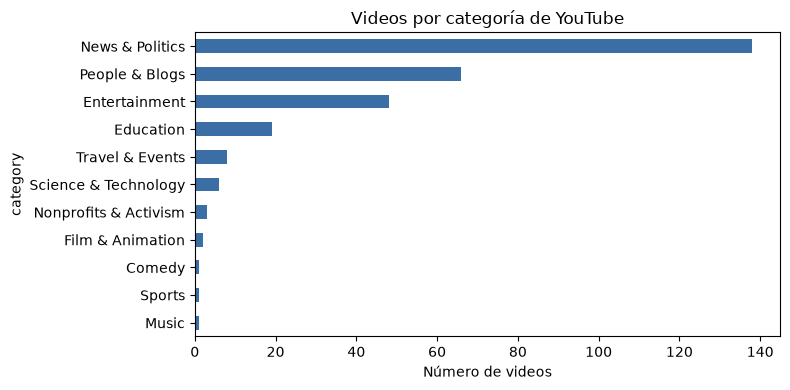

In [325]:
fig, ax = plt.subplots(figsize=(8, 4))
videos['category'].value_counts().plot(kind='barh', ax=ax, color='#3b6ea5')
ax.invert_yaxis()
ax.set_title('Videos por categoría de YouTube')
ax.set_xlabel('Número de videos')
plt.tight_layout()
plt.savefig('graficos/1_categorias.png')
plt.show()

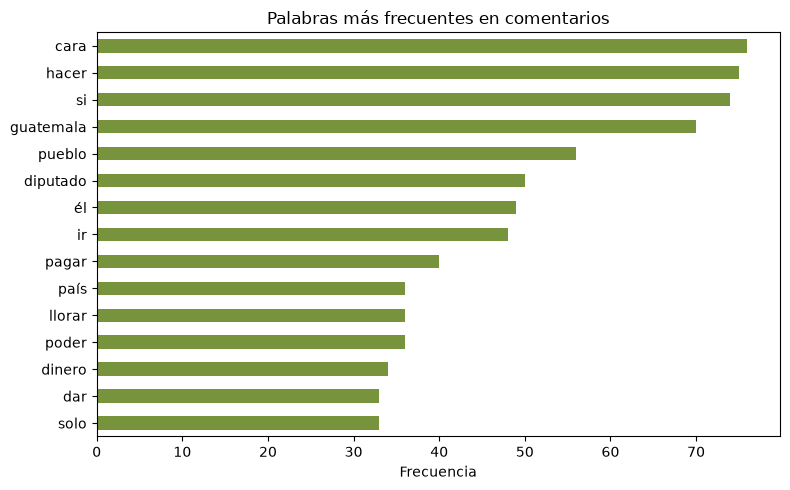

In [326]:
fig, ax = plt.subplots(figsize=(8, 5))
top_palabras.sort_values().plot(kind='barh', ax=ax, color='#77933c')
ax.set_title('Palabras más frecuentes en comentarios')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('graficos/06_palabras_frecuentes.png')
plt.show()

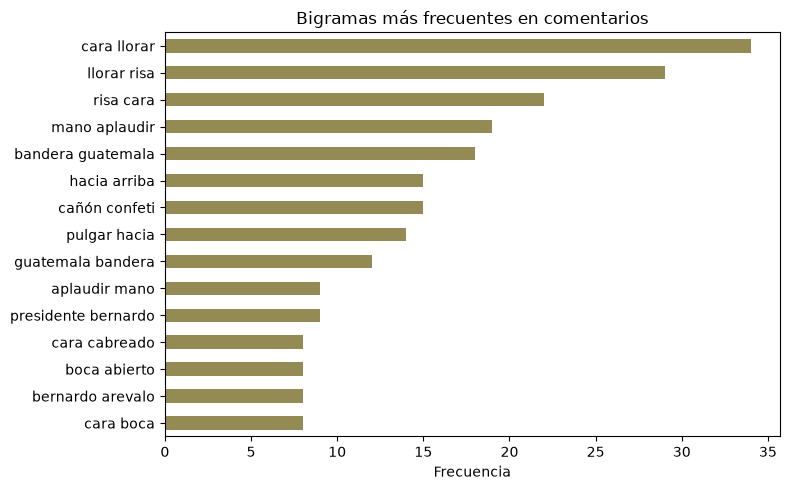

In [327]:
fig, ax = plt.subplots(figsize=(8, 5))
top_bigs.sort_values().plot(kind='barh', ax=ax, color='#948a54')
ax.set_title('Bigramas más frecuentes en comentarios')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('graficos/07_bigramas_frecuentes.png')
plt.show()

### Emojis por separado

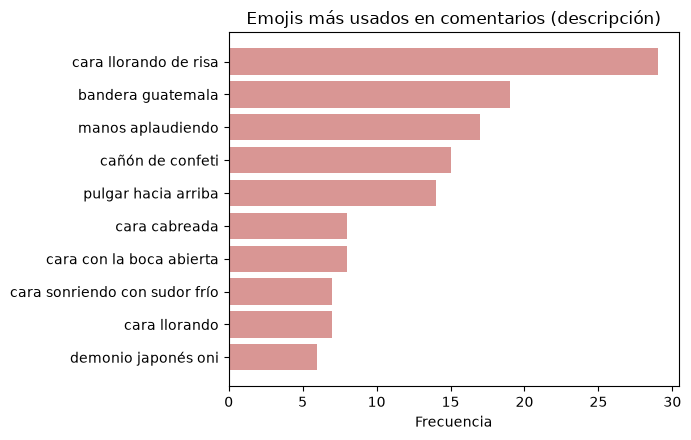

In [328]:
emojis_flat = [e for lst in comments['emojis_extraidos'] for e in lst]
top_emojis = pd.Series(Counter(emojis_flat)).sort_values(ascending=False).head(10)
labels = [emoji.demojize(e, language='es').strip(':').replace('_', ' ') for e in top_emojis.index]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(labels[::-1], top_emojis.values[::-1], color='#d99694')
ax.set_title('Emojis más usados en comentarios (descripción)')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('graficos/09_emojis_frecuentes.png')
plt.show()

## 3.2. Analice la concentración de la participación. Determine qué proporción de comentarios corresponde a los videos y canales más activos.

In [329]:
com_video = comments.groupby('video_id').size().sort_values(ascending=False)
com_canal = comments.groupby('channel_id').size().sort_values(ascending=False)
total_com = len(comments)

top1_video_pct = com_video.head(1).sum() / total_com * 100
top5_video_pct = com_video.head(5).sum() / total_com * 100
top1_canal_pct = com_canal.head(1).sum() / total_com * 100
top5_canal_pct = com_canal.head(5).sum() / total_com * 100
print(top1_video_pct, top5_video_pct, top1_canal_pct, top5_canal_pct)

top_videos_info = videos.set_index('video_id').loc[com_video.head(5).index, ['title', 'channel_name', 'view_count']]
top_videos_info['n_comentarios'] = com_video.head(5).values
print(top_videos_info)

39.6551724137931 75.36945812807882 63.05418719211823 96.05911330049261
                                                         title  \
video_id                                                         
n8iP75gIpmw                          Qué rico come tu diputado   
j43HgwYFKfk      La cooptación de Walter Mazariegos en la USAC   
6W4u8sGEnGM  Inician los trabajos de recuperación del Puent...   
lj983NWyAQY                      Plan 2032 Ciudad de Guatemala   
PjmxCj-a9Hg  Conferencia de Prensa del Gobierno de Guatemal...   

                                      channel_name  view_count  n_comentarios  
video_id                                                                       
n8iP75gIpmw                                 Quorum       11775            161  
j43HgwYFKfk                                 Quorum       10156             50  
6W4u8sGEnGM  Gobierno de la República de Guatemala       11670             45  
lj983NWyAQY             Municipalidad de Guatemala      304089    

### Curva de concentración

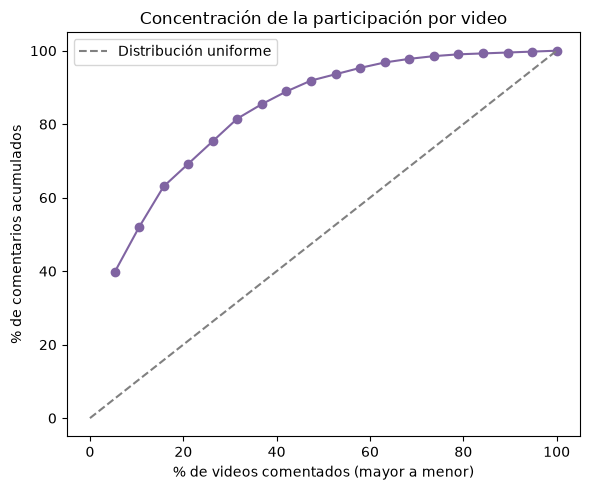

In [330]:
com_sorted = com_video.values
cum_pct = com_sorted.cumsum() / com_sorted.sum() * 100
video_pct = pd.RangeIndex(1, len(com_sorted) + 1) / len(com_sorted) * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(video_pct, cum_pct, marker='o', color='#8064a2')
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Distribución uniforme')
ax.set_xlabel('% de videos comentados (mayor a menor)')
ax.set_ylabel('% de comentarios acumulados')
ax.set_title('Concentración de la participación por video')
ax.legend()
plt.tight_layout()
plt.savefig('graficos/03_concentracion_videos.png')
plt.show()


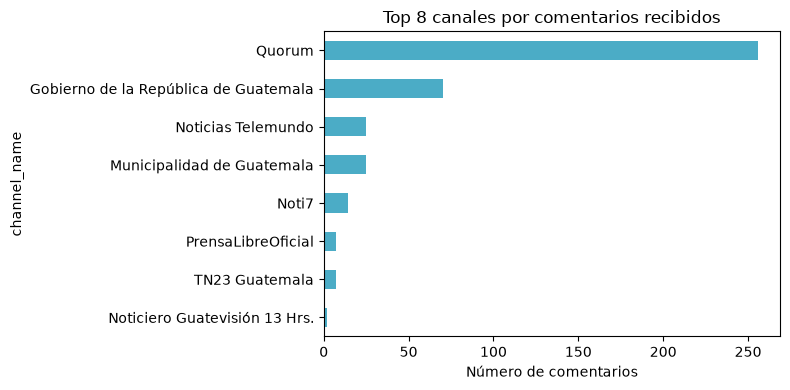

In [331]:
com_canal_nombre = comments.groupby('channel_name').size().sort_values(ascending=False).head(8)
fig, ax = plt.subplots(figsize=(8, 4))
com_canal_nombre.plot(kind='barh', ax=ax, color='#4bacc6')
ax.invert_yaxis()
ax.set_title('Top 8 canales por comentarios recibidos')
ax.set_xlabel('Número de comentarios')
plt.tight_layout()
plt.savefig('graficos/04_top_canales_comentarios.png')
plt.show()

## 3.3. Compare popularidad y participación. Evalúe la relación entre visualizaciones y comentarios, indicando las limitaciones de ambos conteos

               view_count  n_comentarios
view_count       1.000000       0.066866
n_comentarios    0.066866       1.000000
               view_count  n_comentarios
view_count       1.000000       0.811497
n_comentarios    0.811497       1.000000


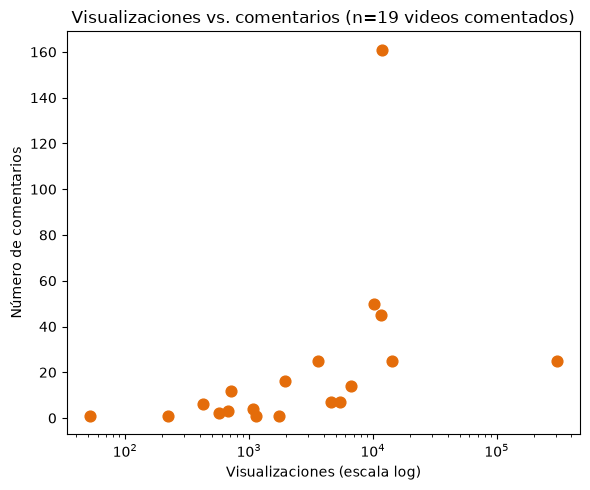

In [332]:
merged = videos.merge(com_video.rename('n_comentarios'), left_on='video_id', right_index=True, how='inner')
print(merged[['view_count', 'n_comentarios']].corr(method='pearson'))
print(merged[['view_count', 'n_comentarios']].corr(method='spearman'))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(merged['view_count'], merged['n_comentarios'], color='#e46c0a', s=60)
ax.set_xscale('log')
ax.set_xlabel('Visualizaciones (escala log)')
ax.set_ylabel('Número de comentarios')
ax.set_title('Visualizaciones vs. comentarios (n=19 videos comentados)')
plt.tight_layout()
plt.savefig('graficos/05_vistas_vs_comentarios.png')
plt.show()

## 3.4. Genere visualizaciones pertinentes. Puede incluir una nube de palabras, pero esta no sustituye gráficos de frecuencia o comparaciones cuantitativas.

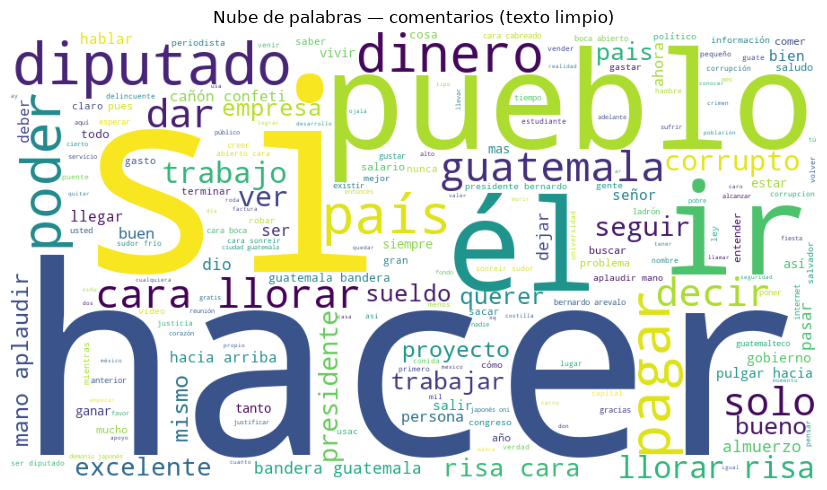

In [333]:
from wordcloud import WordCloud

texto_todo = ' '.join(comments['texto_limpio'].fillna(''))
wc = WordCloud(width=900, height=500, background_color='white', colormap='viridis').generate(texto_todo)

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(wc)
ax.axis('off')
ax.set_title('Nube de palabras — comentarios (texto limpio)')
plt.tight_layout()
plt.savefig('graficos/08_wordcloud.png')
plt.show()

## 3.5. Responda las siguientes preguntas:

¿Qué videos y canales concentran la mayor participación? El video "Qué rico come tu diputado" de Quorum (161 comentarios, 39.7% del total) y el canal Quorum en general (63.1% de todos los comentarios). Es un canal de humor/crítica política, no un medio de noticias tradicional, dato relevante para el análisis de comunidades.

¿Existen audiencias compartidas? Sí, pero limitadas: de 332 autores únicos, solo 9 comentaron en más de un video y 4 comentaron en más de un canal. Es poca gente, pero conecta contenidos que de otro modo estarían aislados. Por ejemplo, un mismo autor comentó en "Qué rico come tu diputado", "La cooptación de Walter Mazariegos" y "10 preguntas a un año del Paro Nacional" (los tres de temática política/institucional).

¿Qué autores funcionan como puentes? Los mismos 9 autores de arriba, son candidatos naturales a "puente" en la red bipartita que construirás en la sección 4-5. Uno de ellos conecta 3 videos distintos.

¿Temas y sentimientos en las principales comunidades? A nivel exploratorio (el análisis formal de sentimiento va en la sección 9), el vocabulario dominante "pueblo", "corrupto", "diputado", "pagar", "dinero", "sueldo" y bigramas como "pacto corrupto", "dinero pueblo", "morir hambre" apuntan a un tono predominantemente crítico/indignado hacia la clase política, no conversación neutra o informativa.

¿La visibilidad coincide con la participación? No de forma directa (ver 3.3): el video más visto no es el más comentado. La popularidad medida en vistas y el "engagement" activo (comentar) parecen fenómenos distintos en este dataset.

¿Qué conclusiones están limitadas por la recolección? Principalmente que solo el 6.5% de los videos tiene comentarios cualquier conclusión sobre "qué genera más conversación" se basa en apenas 19 casos, seleccionados por un proceso de muestreo (no aleatorio) que combina búsquedas temáticas y canales oficiales específicos.

In [334]:
autores_por_video_n = comments.groupby('author_channel_id')['video_id'].nunique().sort_values(ascending=False)
print("autores en más de 1 video:", (autores_por_video_n > 1).sum(), "de", n_autores)

autores_por_canal_n = comments.groupby('author_channel_id')['channel_id'].nunique().sort_values(ascending=False)
print("autores en más de 1 canal:", (autores_por_canal_n > 1).sum())

autores_puente = autores_por_video_n[autores_por_video_n > 1].index
ejemplo_puentes = comments[comments['author_channel_id'].isin(autores_puente)].groupby('author_channel_id')['video_id'].apply(list)
print(ejemplo_puentes)

autores en más de 1 video: 9 de 332
autores en más de 1 canal: 4
author_channel_id
UCHTGCgY2l-DQJIvlA_cpa_Q              [n8iP75gIpmw, n8iP75gIpmw, PjmxCj-a9Hg]
UCbrtvygfRT6QXqWDNrOf-cA                           [yLZS3JiEBg8, ndAZjHqzzT8]
UCdFlugHJJa4l3YqWuNRmvXw                           [j43HgwYFKfk, is3Mk5oC19g]
UCjZgFEowMBrsjodqfovzdKw                           [6W4u8sGEnGM, 06mFNPU0aB8]
UCpsKOkt5iWTbenzeuq7dsmQ              [ndAZjHqzzT8, j43HgwYFKfk, n8iP75gIpmw]
UCsUCN0Yq_UyTvKjOJLmNrnQ                           [n8iP75gIpmw, b_Hkrkl3adA]
UCvcu1kR8xMYy_I1Ty-2mV2Q    [yLZS3JiEBg8, WIUZtitfLRw, ndAZjHqzzT8, ndAZjH...
UCylqlpsh8ENNM1LqgQ1KbxA              [j43HgwYFKfk, j43HgwYFKfk, n8iP75gIpmw]
UCzZ6dDCEsLMXbc5pCFXIprw                           [6W4u8sGEnGM, PjmxCj-a9Hg]
Name: video_id, dtype: object


### 3.6. Formule al menos tres preguntas adicionales que surjan del análisis exploratorio y respóndalas con evidencia obtenida de los datos.

¿El tipo de fuente de recolección (source_group) se relaciona con el nivel de interacción del comentario? Sí, y de forma marcada: los comentarios recolectados vía topic (búsqueda temática) tienen un promedio de 11.0 "me gusta", mientras que los recolectados vía channel (canal específico) tienen solo 1.7 en promedio. Esto sugiere que el contenido encontrado por tema/tendencia genera más reacción que el contenido institucional de canal fijo, aunque también podría ser un artefacto de qué videos concretos cayeron en cada grupo.

¿Los comentarios con más respuestas (reply_count) también reciben más "me gusta"? Sí, correlación moderada-positiva (r = 0.54). Tiene sentido: un comentario que genera debate (respuestas) suele ser también uno que la gente valida o rebate activamente con "me gusta".

¿Comentarios más largos reciben más "me gusta"? No hay relación (r = -0.04, prácticamente cero). La extensión del comentario no predice su popularidad, comentarios cortos y contundentes tienen tanta chance de ser "likeados" como uno largo.

In [335]:
print(comments.groupby('source_group')['like_count'].mean())
print(comments[['reply_count', 'like_count']].corr())
print(comments[['longitud_palabras', 'like_count']].corr())

source_group
channel     1.722944
topic      11.011429
Name: like_count, dtype: float64
             reply_count  like_count
reply_count     1.000000    0.536626
like_count      0.536626    1.000000
                   longitud_palabras  like_count
longitud_palabras            1.00000    -0.03686
like_count                  -0.03686     1.00000


## 4. Construcción de la red bipartita autor-video

### 4.1. Construya una red bipartita no dirigida en la que un conjunto de nodos represente autores y el otro represente videos.

In [336]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

edges_df = (
    comments
    .dropna(subset=['author_channel_id', 'video_id'])
    .groupby(['author_channel_id', 'video_id'])
    .size()
    .reset_index(name='weight')
)

B = nx.Graph() 

autores_info = (
    comments.groupby('author_channel_id')
    .agg(author_name=('author_name', 'first'),
         n_comentarios=('comment_id', 'count'),
         n_videos_comentados=('video_id', 'nunique'))
    .reset_index()
)

for _, row in autores_info.iterrows():
    B.add_node(row['author_channel_id'],
               bipartite='autor', tipo='autor',
               nombre=row['author_name'],
               n_comentarios=int(row['n_comentarios']),
               n_videos=int(row['n_videos_comentados']))

### 4.2. Cree una arista cuando un autor haya comentado en un video. Asigne como peso el número de comentarios publicados por ese autor en ese video.

In [337]:
videos_indexed = videos.set_index('video_id')
for vid in edges_df['video_id'].unique():
    if vid in videos_indexed.index:
        vinfo = videos_indexed.loc[vid]
        titulo = vinfo['title'] if not isinstance(vinfo, pd.DataFrame) else vinfo['title'].iloc[0]
        canal  = vinfo['channel_name'] if not isinstance(vinfo, pd.DataFrame) else vinfo['channel_name'].iloc[0]
        categoria = vinfo['category'] if not isinstance(vinfo, pd.DataFrame) else vinfo['category'].iloc[0]
    else:
        titulo, canal, categoria = 'Desconocido', 'Desconocido', 'Desconocido'
    B.add_node(vid, bipartite='video', tipo='video',
               titulo=titulo, canal=canal, categoria=categoria)

# --- Aristas con peso ---
for _, row in edges_df.iterrows():
    B.add_edge(row['author_channel_id'], row['video_id'], weight=int(row['weight']))

print("Nodos totales:", B.number_of_nodes())
print("  - autores:", sum(1 for n,d in B.nodes(data=True) if d['tipo']=='autor'))
print("  - videos:", sum(1 for n,d in B.nodes(data=True) if d['tipo']=='video'))
print("Aristas totales:", B.number_of_edges())

Nodos totales: 351
  - autores: 332
  - videos: 19
Aristas totales: 343


### 4.3. Construya y entregue una tabla de nodos y una tabla de aristas. Incluya tipo de nodo y atributos relevantes

In [338]:
nodos_tabla = pd.DataFrame([{'id': n, **d} for n, d in B.nodes(data=True)])

aristas_tabla = pd.DataFrame([
    {'autor': u if B.nodes[u]['tipo']=='autor' else v,
     'video': v if B.nodes[v]['tipo']=='video' else u,
     'weight': d['weight']}
    for u, v, d in B.edges(data=True)
])

nodos_tabla.head()
aristas_tabla.head()

,autor,video,weight
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1


### 4.4. Visualice la red completa, evite eliminar estructuras relevantes únicamente para mejorar la apariencia.

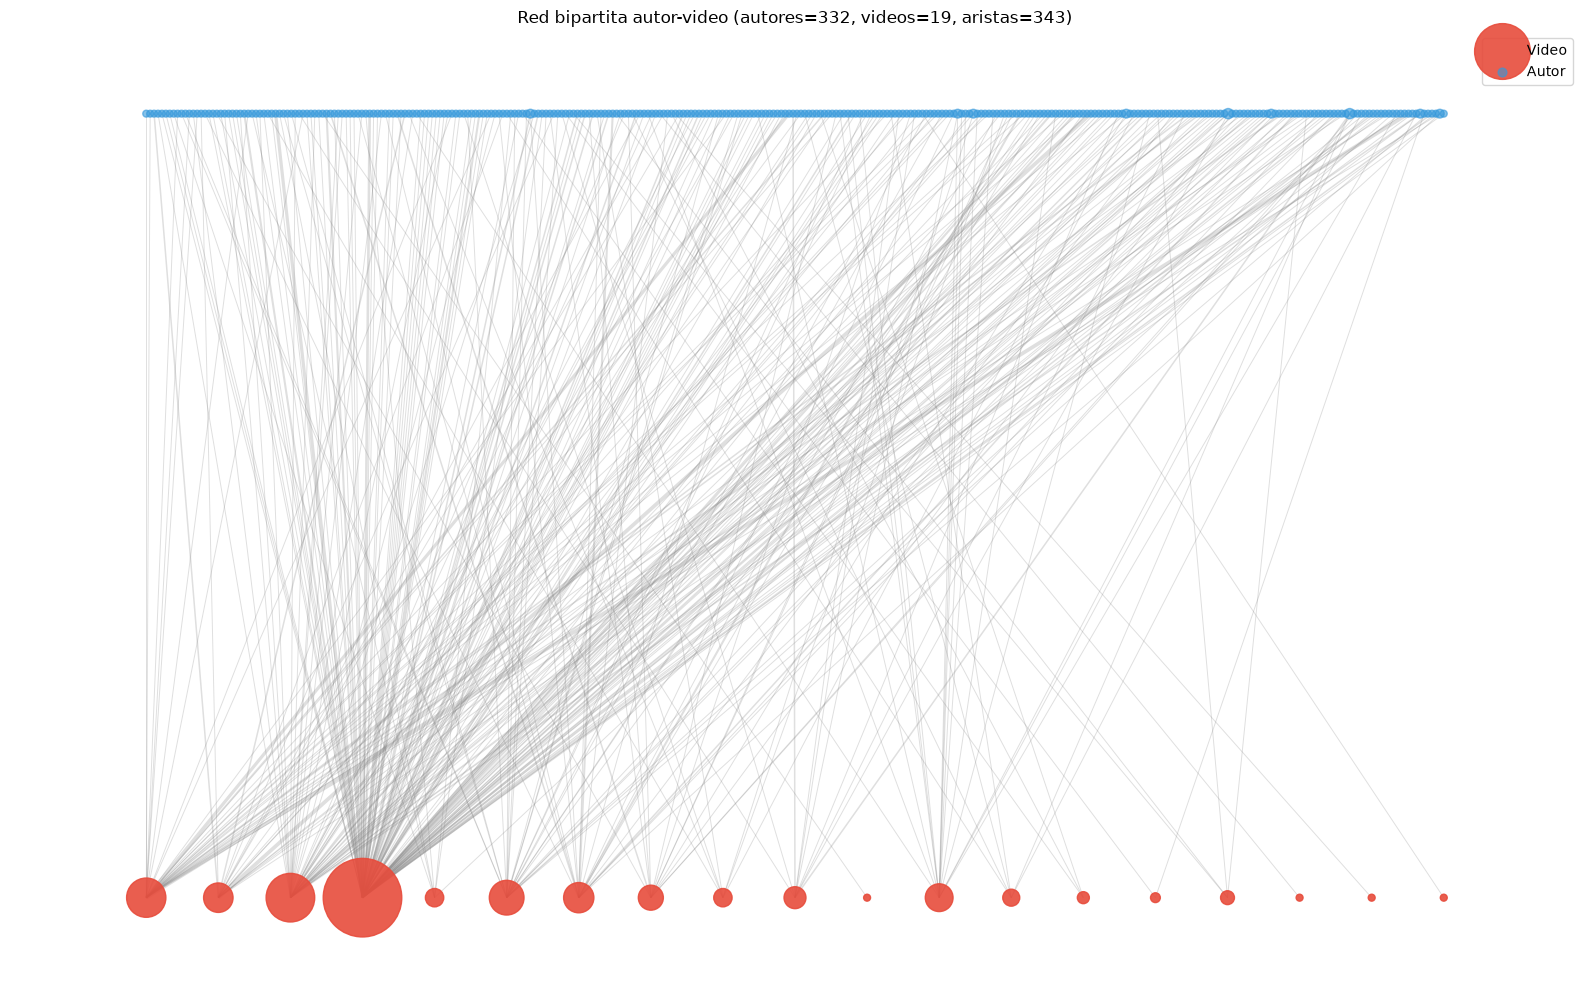

In [339]:
plt.figure(figsize=(16, 10))

autores = [n for n, d in B.nodes(data=True) if d['tipo'] == 'autor']
video_nodes = [n for n, d in B.nodes(data=True) if d['tipo'] == 'video']

pos = nx.bipartite_layout(B, video_nodes, align='horizontal', scale=2)

video_sizes = [B.degree(v) * 25 for v in video_nodes]      # tamaño ~ nº de autores distintos
autor_sizes = [B.degree(a) * 15 + 10 for a in autores]      # tamaño ~ nº de videos comentados
weights = [B[u][v]['weight'] for u, v in B.edges()]

nx.draw_networkx_nodes(B, pos, nodelist=video_nodes, node_color='#e74c3c',
                        node_size=video_sizes, label='Video', alpha=0.9)
nx.draw_networkx_nodes(B, pos, nodelist=autores, node_color='#3498db',
                        node_size=autor_sizes, label='Autor', alpha=0.6)
nx.draw_networkx_edges(B, pos, width=[0.3 + 0.4*w for w in weights],
                        alpha=0.25, edge_color='gray')

plt.legend(scatterpoints=1)
plt.title(f'Red bipartita autor-video (autores={len(autores)}, videos={len(video_nodes)}, aristas={B.number_of_edges()})')
plt.axis('off')
plt.tight_layout()
plt.savefig('graficos/red_bipartita.png', dpi=150)
plt.show()

### 4.5. Explique con precisión qué significa una arista. No interprete la co-participación como amistad, conversación directa ni aprobación.

Una arista en esta red bipartita conecta a un autor con un video si y solo si ese autor publicó al menos un comentario principal en ese video. El peso de la arista es el número de comentarios que ese autor específico dejó en ese video en particular, no es una medida de interacción entre personas.

Es importante no sobreinterpretar esta arista:

No implica amistad ni relación social entre el autor y el canal/creador del video, ni entre autores.
No implica conversación directa: dos autores que comentaron el mismo video no necesariamente se leyeron, respondieron o dialogaron entre sí (de hecho, como aclara el enunciado del laboratorio, reply_count no identifica a los autores de las respuestas, así que no hay forma de reconstruir quién respondió a quién).
No implica aprobación ni acuerdo con el contenido del video, un comentario puede ser crítico, sarcástico o negativo y aun así generar la arista.
Lo único que la arista certifica es co-presencia observada: el autor participó en ese espacio de comentarios. Cualquier interpretación de comunidad, cercanía temática o "audiencia compartida" (que sí exploran en el punto 5, proyecciones) es una inferencia estructural sobre patrones de co-participación, no evidencia directa de interacción social.

In [340]:
# Tablas a CSV
nodos_tabla.to_csv('nodos_bipartita.csv', index=False)
aristas_tabla.to_csv('aristas_bipartita.csv', index=False)

# El grafo completo en formato GEXF (abre directo en Gephi)
nx.write_gexf(B, 'red_bipartita.gexf')

# O en GraphML si prefieres
nx.write_graphml(B, 'red_bipartita.graphml')

### exportación de parte 4

In [341]:
# Tablas a CSV
nodos_tabla.to_csv('nodos_bipartita.csv', index=False)
aristas_tabla.to_csv('aristas_bipartita.csv', index=False)

# El grafo completo en formato GEXF (abre directo en Gephi)
nx.write_gexf(B, 'red_bipartita.gexf')

# O en GraphML si prefieres
nx.write_graphml(B, 'red_bipartita.graphml')